# Wahl-O-Mat Feature Analysis

In [1]:
%load_ext autoreload
%autoreload 2
import helper
import plotting
import constants
import pandas as pd
from datetime import datetime
import numpy as np
import ast
import matplotlib.pyplot as plt
import pm4py

In [2]:
berlin_df = pm4py.read_xes("./data-xes/Berlin-with-topics-and-agreement-scores-all-time.xes")
brandenburg_df = pm4py.read_xes("./data-xes/Brandenburg-with-topics-and-agreement-scores-all-time.xes")
bawue_df = pm4py.read_xes("./data-xes/Baden-Württemberg-with-topics-and-agreement-scores-all-time.xes")

# Berlin:
start_date_berlin = "2006-10-26"
end_date_berlin = "2021-11-04"
# Brandenburg:
start_date_brandenburg = "2004-10-13"
end_date_brandenburg = "2019-09-25"
# Baden-Württemberg:
start_date_bawue = "2006-06-01"
end_date_bawue = "2021-05-01"

date_filter_on = True

only_passed_bill_traces = True

parsing log, completed traces ::   0%|          | 0/1813 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/1410 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/1465 [00:00<?, ?it/s]

In [3]:
passed_bills_activities_berlin = ['Gesetz- und Verordnungsblatt', 'Bekanntmachung (Gesetz- und Verordnungsblatt)']
passed_bills_activities_bawue = ["Gesetz", "Gesetzblatt für Baden-Württemberg"]
passed_bills_activities_brandenburg = ["Gesetz", "Gesetz- und Verordnungsblatt"]

possible_passed_bills_activities = passed_bills_activities_berlin + passed_bills_activities_bawue + passed_bills_activities_brandenburg

def generate_passed_bill_column(df):
    df["is_passed_bill"] = df.groupby("case:concept:name")["concept:name"].transform(lambda x: x.isin(possible_passed_bills_activities).any())
    return df

def generate_end_date_column(df):
    df["end_time"] = (
        df.groupby("case:concept:name")["time:timestamp"]
        .transform("max")
    )
    return df

def generate_start_date_column(df):
    df["start_time"] = (
        df.groupby("case:concept:name")["time:timestamp"]
        .transform("min")
    )
    return df

berlin_df = generate_passed_bill_column(berlin_df)
berlin_df = generate_end_date_column(berlin_df)
berlin_df = generate_start_date_column(berlin_df)
brandenburg_df = generate_passed_bill_column(brandenburg_df)
brandenburg_df = generate_end_date_column(brandenburg_df)
brandenburg_df = generate_start_date_column(brandenburg_df)
bawue_df = generate_passed_bill_column(bawue_df)
bawue_df = generate_end_date_column(bawue_df)
bawue_df = generate_start_date_column(bawue_df)

In [4]:
# filter the data by date
if date_filter_on:
    print("------------------ Berlin, Brandenburg, Baden-Württemberg")
    print("df rows before filtering by date:", str(len(berlin_df)) + ", " + str(len(brandenburg_df)) + ", " + str(len(bawue_df)))

    berlin_df = berlin_df[(berlin_df['start_time'] >= start_date_berlin) & (berlin_df['end_time'] <= end_date_berlin)]
    brandenburg_df = brandenburg_df[(brandenburg_df['start_time'] >= start_date_brandenburg) & (brandenburg_df['end_time'] <= end_date_brandenburg)]
    bawue_df = bawue_df[(bawue_df['start_time'] >= start_date_bawue) & (bawue_df['end_time'] <= end_date_bawue)]

    print("df rows after filtering by date:", str(len(berlin_df)) + ", " + str(len(brandenburg_df)) + ", " + str(len(bawue_df)))

# filter only passed bills
if only_passed_bill_traces:
    print("------------------ Berlin, Brandenburg, Baden-Württemberg")
    print("df rows before filtering only passed bills:", str(len(berlin_df)) + ", " + str(len(brandenburg_df)) + ", " + str(len(bawue_df)))

    berlin_df = berlin_df[berlin_df["is_passed_bill"] == True]
    brandenburg_df = brandenburg_df[brandenburg_df["is_passed_bill"] == True]
    bawue_df = bawue_df[bawue_df["is_passed_bill"] == True]

    print("df rows after filtering only passed bills:", str(len(berlin_df)) + ", " + str(len(brandenburg_df)) + ", " + str(len(bawue_df)))    

------------------ Berlin, Brandenburg, Baden-Württemberg
df rows before filtering by date: 14422, 13263, 10000
df rows after filtering by date: 5262, 4979, 3763
------------------ Berlin, Brandenburg, Baden-Württemberg
df rows before filtering only passed bills: 5262, 4979, 3763
df rows after filtering only passed bills: 4192, 4508, 2409


In [5]:
def meanCycleTime(dataframe):
    cycle_times = cycleTimes(dataframe)
    return np.mean(cycle_times)

def cycleTimes(dataframe):
    # Get all case durations in seconds
    durations = pm4py.get_all_case_durations(dataframe)
    # Convert to days    
    durations_in_days = np.array(durations)/60/60/24
    return durations_in_days



# Calculate cycle time per case and broadcast to all rows in the case
berlin_df['cycle_time'] = berlin_df.groupby('case:concept:name')["time:timestamp"].transform(lambda x: x.max() - x.min())
berlin_df['cycle_time_seconds'] = berlin_df['cycle_time'].dt.total_seconds()
berlin_df['cycle_time_days'] = berlin_df['cycle_time_seconds'] / (60 * 60 * 24)
berlin_df_grouped = berlin_df.groupby("case:concept:name").first().reset_index()

brandenburg_df['cycle_time'] = brandenburg_df.groupby('case:concept:name')["time:timestamp"].transform(lambda x: x.max() - x.min())
brandenburg_df['cycle_time_seconds'] = brandenburg_df['cycle_time'].dt.total_seconds()
brandenburg_df['cycle_time_days'] = brandenburg_df['cycle_time_seconds'] / (60 * 60 * 24)
brandenburg_df_grouped = brandenburg_df.groupby("case:concept:name").first().reset_index()

bawue_df['cycle_time'] = bawue_df.groupby('case:concept:name')["time:timestamp"].transform(lambda x: x.max() - x.min())
bawue_df['cycle_time_seconds'] = bawue_df['cycle_time'].dt.total_seconds()
bawue_df['cycle_time_days'] = bawue_df['cycle_time_seconds'] / (60 * 60 * 24)
bawue_df_grouped = bawue_df.groupby("case:concept:name").first().reset_index()

print("len berlin_df_grouped:", len(berlin_df_grouped))
print("len brandenburg_df_grouped:", len(brandenburg_df_grouped))
print("len bawue_df_grouped:", len(bawue_df_grouped))

'''
# Testing if the cycle times are calculated correctly:
# Take one row per case to avoid counting multiple events
cycle_times_per_case = berlin_df[['case:concept:name', 'cycle_time']].drop_duplicates()
mean_cycle_time = cycle_times_per_case['cycle_time'].mean()
print("Mean cycle time per case:", mean_cycle_time)
# Take one row per case to avoid counting multiple events
cycle_times_per_case = bawue_df[['case:concept:name', 'cycle_time']].drop_duplicates()
mean_cycle_time = cycle_times_per_case['cycle_time'].mean()
print("Mean cycle time per case:", mean_cycle_time)
'''


len berlin_df_grouped: 501
len brandenburg_df_grouped: 440
len bawue_df_grouped: 335


'\n# Testing if the cycle times are calculated correctly:\n# Take one row per case to avoid counting multiple events\ncycle_times_per_case = berlin_df[[\'case:concept:name\', \'cycle_time\']].drop_duplicates()\nmean_cycle_time = cycle_times_per_case[\'cycle_time\'].mean()\nprint("Mean cycle time per case:", mean_cycle_time)\n# Take one row per case to avoid counting multiple events\ncycle_times_per_case = bawue_df[[\'case:concept:name\', \'cycle_time\']].drop_duplicates()\nmean_cycle_time = cycle_times_per_case[\'cycle_time\'].mean()\nprint("Mean cycle time per case:", mean_cycle_time)\n'

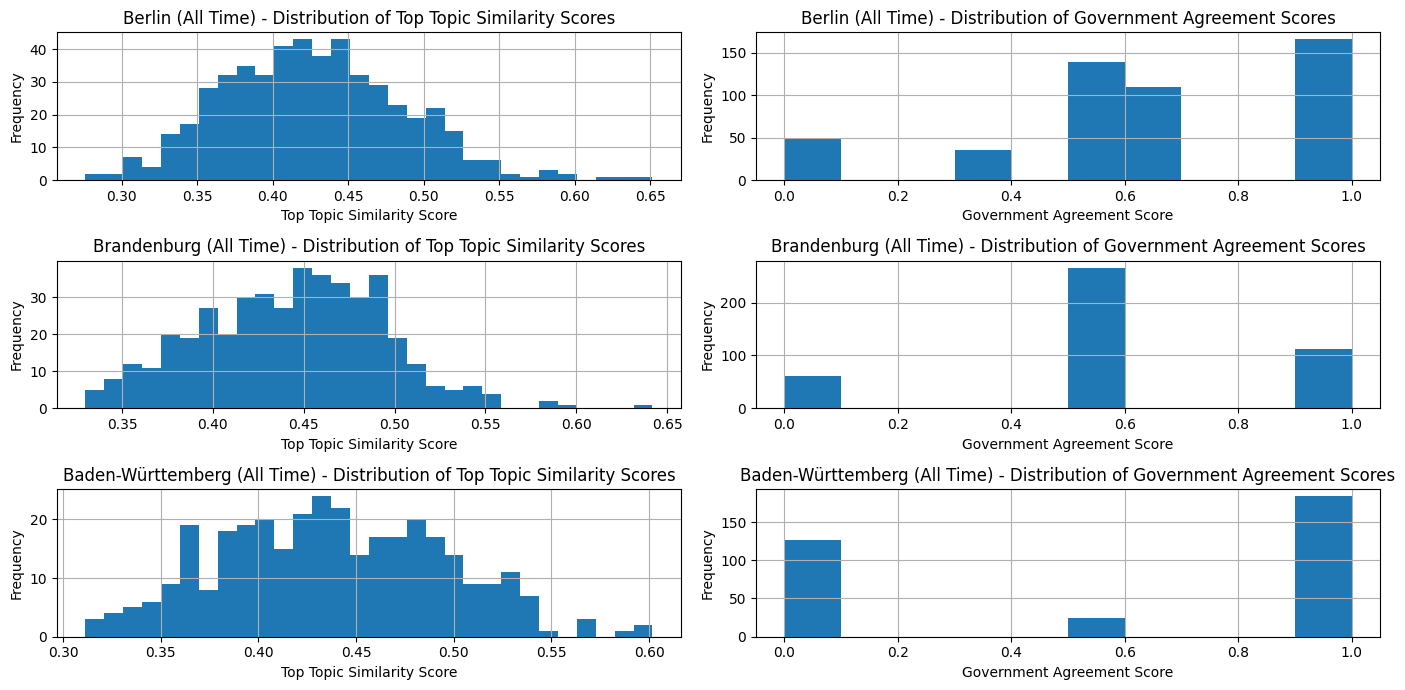

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(14, 7))

berlin_df_grouped["top_topic_similarity_score"].hist(bins=30, ax=axes[0, 0])
axes[0, 0].set_xlabel("Top Topic Similarity Score")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_title("Berlin (All Time) - Distribution of Top Topic Similarity Scores")

berlin_df_grouped["government_agreement_score"].hist(bins=10, ax=axes[0, 1])
axes[0, 1].set_xlabel("Government Agreement Score")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Berlin (All Time) - Distribution of Government Agreement Scores")

brandenburg_df_grouped["top_topic_similarity_score"].hist(bins=30, ax=axes[1, 0])
axes[1, 0].set_xlabel("Top Topic Similarity Score")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_title("Brandenburg (All Time) - Distribution of Top Topic Similarity Scores")

brandenburg_df_grouped["government_agreement_score"].hist(bins=10, ax=axes[1, 1])
axes[1, 1].set_xlabel("Government Agreement Score")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Brandenburg (All Time) - Distribution of Government Agreement Scores")

bawue_df_grouped["top_topic_similarity_score"].hist(bins=30, ax=axes[2, 0])
axes[2, 0].set_xlabel("Top Topic Similarity Score")
axes[2, 0].set_ylabel("Frequency")
axes[2, 0].set_title("Baden-Württemberg (All Time) - Distribution of Top Topic Similarity Scores")

bawue_df_grouped["government_agreement_score"].hist(bins=10, ax=axes[2, 1])
axes[2, 1].set_xlabel("Government Agreement Score")
axes[2, 1].set_ylabel("Frequency")
axes[2, 1].set_title("Baden-Württemberg (All Time) - Distribution of Government Agreement Scores")

plt.tight_layout()
plt.show()

# Correlations Cycle Times and Agreement Scores

In [7]:
from scipy.stats import pearsonr, spearmanr, kendalltau
import matplotlib.pyplot as plt
import seaborn as sns

def test_correlations(dataframe, target_col, plot=False, origin_col="cycle_time"):

    if dataframe.empty:
        print("No rows left after filtering top_topic_similarity_score.")
        return

    if origin_col == "cycle_time":
        # Convert cycle_time to numeric seconds
        #dataframe['cycle_time_seconds'] = dataframe['cycle_time'].dt.total_seconds()
        #x = dataframe['cycle_time_seconds']
        x = dataframe['cycle_time_days']
    else:
        x = dataframe[origin_col]

    y = dataframe[target_col]
    
    # Pearson test
    pearson_corr, pearson_p = pearsonr(x, y)
    print(f"Pearson correlation: {pearson_corr:.3f}, p-value: {pearson_p:.3f}")
    
    # Spearman test
    spearman_corr, spearman_p = spearmanr(x, y)
    print(f"Spearman correlation: {spearman_corr:.3f}, p-value: {spearman_p:.3f}")
    
    # Kendall tau test
    kendall_corr, kendall_p = kendalltau(x, y)
    print(f"Kendall tau correlation: {kendall_corr:.3f}, p-value: {kendall_p:.3f}")
    
    # Optional scatter plot with regression line
    if plot:
        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=x, y=y, s=50, alpha=0.7)
        sns.regplot(x=x, y=y, scatter=False, color='orange', line_kws={"linewidth":1})
        if origin_col == "cycle_time":
            plt.xlabel("Cycle time (days)")
        else:
            plt.xlabel(origin_col)
        plt.ylabel(target_col)
        plt.title(f"Cycle time vs {target_col}\nPearson r={pearson_corr:.2f}, p={pearson_p:.3f}")
        plt.tight_layout()
        plt.show()


In [8]:
'''
withPlots = True

def test_correlations_groups(dataframe, lower_threshold, upper_threshold, withPlots):

    dataframe = dataframe[
        dataframe["top_topic_similarity_score"].between(
            lower_threshold,
            upper_threshold,
            inclusive="both"
        )
    ].copy()

    print(f"Testing correlations for top_topic_similarity_score between {lower_threshold} and {upper_threshold}...")
    print(f"Number of cases in this group: {len(dataframe)}")

    print("\ngovernment agreement score:")
    test_correlations(dataframe, 'government_agreement_score', withPlots)
    print("\nopposition agreement score:")
    test_correlations(dataframe, 'opposition_agreement_score', withPlots)
    print("\nall agreement score:")
    test_correlations(dataframe, 'all_agreement_score', withPlots)
    print("\nis_passed_bill government agreement score:")
    test_correlations(dataframe, 'government_agreement_score', withPlots, "is_passed_bill")
    print("\n\n-----------------------------------\n\n")

print("Berlin ALL TIME - Correlation between cycle time and ...")
test_correlations_groups(berlin_df_grouped, 0.5, 1, withPlots)

print("Brandenburg ALL TIME - Correlation between cycle time and ...")
test_correlations_groups(brandenburg_df_grouped, 0.5, 1, withPlots)

print("Baden-Württemberg ALL TIME - Correlation between cycle time and ...")
test_correlations_groups(bawue_df_grouped, 0.5, 1, withPlots)
'''


'\nwithPlots = True\n\ndef test_correlations_groups(dataframe, lower_threshold, upper_threshold, withPlots):\n\n    dataframe = dataframe[\n        dataframe["top_topic_similarity_score"].between(\n            lower_threshold,\n            upper_threshold,\n            inclusive="both"\n        )\n    ].copy()\n\n    print(f"Testing correlations for top_topic_similarity_score between {lower_threshold} and {upper_threshold}...")\n    print(f"Number of cases in this group: {len(dataframe)}")\n\n    print("\ngovernment agreement score:")\n    test_correlations(dataframe, \'government_agreement_score\', withPlots)\n    print("\nopposition agreement score:")\n    test_correlations(dataframe, \'opposition_agreement_score\', withPlots)\n    print("\nall agreement score:")\n    test_correlations(dataframe, \'all_agreement_score\', withPlots)\n    print("\nis_passed_bill government agreement score:")\n    test_correlations(dataframe, \'government_agreement_score\', withPlots, "is_passed_bill")\

## Group comparisons

In [9]:
import pandas as pd
import numpy as np

# binary agreement group
berlin_df_grouped["high_agreement"] = berlin_df_grouped["government_agreement_score"] == 1
brandenburg_df_grouped["high_agreement"] = brandenburg_df_grouped["government_agreement_score"] == 1
bawue_df_grouped["high_agreement"] = bawue_df_grouped["government_agreement_score"] == 1

# log transform cycle time
berlin_df_grouped["log_cycle_time"] = np.log(berlin_df_grouped["cycle_time_days"])
brandenburg_df_grouped["log_cycle_time"] = np.log(brandenburg_df_grouped["cycle_time_days"])
bawue_df_grouped["log_cycle_time"] = np.log(bawue_df_grouped["cycle_time_days"])

# only high topic similarity score
# ToDo: define this better than arbitrary threshold of 0.5!
'''
berlin_threshold = berlin_df_grouped["top_topic_similarity_score"].quantile(0.80)  # keep the top 25%
print("Berlin top_topic_similarity_score threshold for top 20%:", berlin_threshold)
berlin_df_grouped = berlin_df_grouped[
        berlin_df_grouped["top_topic_similarity_score"].between(
            berlin_threshold,
            1,
            inclusive="both"
        )
    ].copy()

brandenburg_threshold = brandenburg_df_grouped["top_topic_similarity_score"].quantile(0.80)  # keep the top 25%
print("Brandenburg top_topic_similarity_score threshold for top 20%:", brandenburg_threshold)
brandenburg_df_grouped = brandenburg_df_grouped[
        brandenburg_df_grouped["top_topic_similarity_score"].between(
            brandenburg_threshold,
            1,
            inclusive="both"
        )
    ].copy()


bawue_threshold = bawue_df_grouped["top_topic_similarity_score"].quantile(0.80)  # keep the top 25%
print("Baden-Württemberg top_topic_similarity_score threshold for top 20%:", bawue_threshold)
bawue_df_grouped = bawue_df_grouped[
        bawue_df_grouped["top_topic_similarity_score"].between(
            bawue_threshold,
            1,
            inclusive="both"
        )
    ].copy()
'''

'\nberlin_threshold = berlin_df_grouped["top_topic_similarity_score"].quantile(0.80)  # keep the top 25%\nprint("Berlin top_topic_similarity_score threshold for top 20%:", berlin_threshold)\nberlin_df_grouped = berlin_df_grouped[\n        berlin_df_grouped["top_topic_similarity_score"].between(\n            berlin_threshold,\n            1,\n            inclusive="both"\n        )\n    ].copy()\n\nbrandenburg_threshold = brandenburg_df_grouped["top_topic_similarity_score"].quantile(0.80)  # keep the top 25%\nprint("Brandenburg top_topic_similarity_score threshold for top 20%:", brandenburg_threshold)\nbrandenburg_df_grouped = brandenburg_df_grouped[\n        brandenburg_df_grouped["top_topic_similarity_score"].between(\n            brandenburg_threshold,\n            1,\n            inclusive="both"\n        )\n    ].copy()\n\n\nbawue_threshold = bawue_df_grouped["top_topic_similarity_score"].quantile(0.80)  # keep the top 25%\nprint("Baden-Württemberg top_topic_similarity_score thresh

------------------ Berlin
U statistic: 26746.0
p-value: 0.48767158854614323
                count           median                        mean  \
high_agreement                                                       
False             335 97 days 00:00:00 141 days 03:47:49.253731344   
True              166 97 days 12:00:00 121 days 19:57:06.506024096   

                                       std  
high_agreement                              
False          149 days 03:17:32.811507436  
True           101 days 22:11:15.943495645  


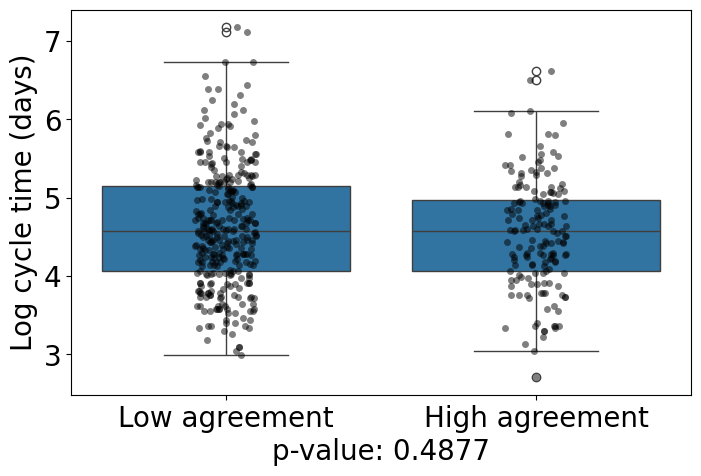

------------------ Brandenburg
U statistic: 18504.0
p-value: 0.9808296817280046
                count   median                        mean  \
high_agreement                                               
False             327 115 days 149 days 21:25:52.293577982   
True              113 123 days 141 days 05:44:04.247787610   

                                       std  
high_agreement                              
False          121 days 03:39:47.640413700  
True            90 days 15:17:47.365934886  


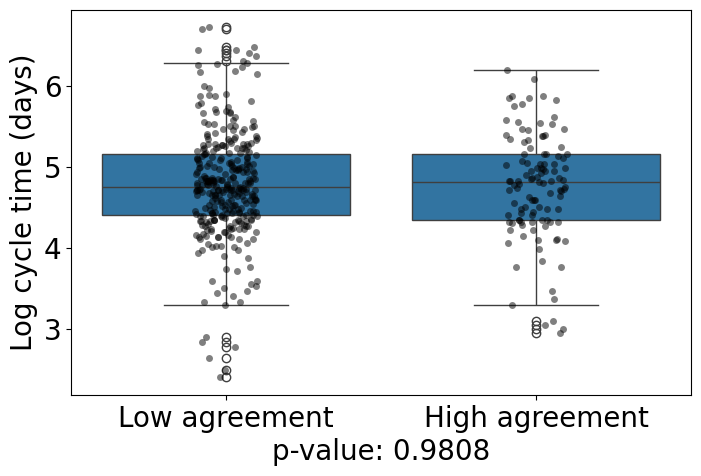

------------------ Baden-Württemberg
U statistic: 13592.0
p-value: 0.7341461903482023
                count  median                       mean  \
high_agreement                                             
False             151 69 days 90 days 00:28:36.556291391   
True              184 69 days 91 days 18:23:28.695652174   

                                       std  
high_agreement                              
False           98 days 12:32:02.045234822  
True           104 days 07:18:18.604757914  


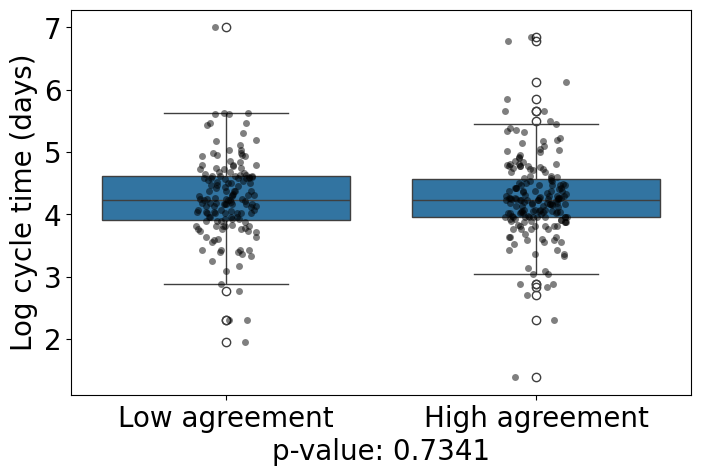

In [10]:
from scipy.stats import mannwhitneyu

for (parliament, df) in [("Berlin", berlin_df_grouped), ("Brandenburg", brandenburg_df_grouped), ("Baden-Württemberg", bawue_df_grouped)]:
    print("------------------", parliament)
    group_high = df[df["high_agreement"]]["cycle_time"]
    group_low = df[~df["high_agreement"]]["cycle_time"]

    # run test
    u_stat, p_value = mannwhitneyu(group_high, group_low, alternative="two-sided")

    print(f"U statistic: {u_stat}")
    print(f"p-value: {p_value}")
    summary = df.groupby("high_agreement")["cycle_time"].agg(
    ["count", "median", "mean", "std"]
    )
    print(summary)

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="high_agreement",
        y="log_cycle_time"
    )

    sns.stripplot(
        data=df,
        x="high_agreement",
        y="log_cycle_time",
        color="black",
        alpha=0.5,
        jitter=True
    )

    plt.xticks([0, 1], ["Low agreement", "High agreement"], fontsize=20)
    plt.yticks(fontsize=20)
    plt.ylabel("Log cycle time (days)", fontsize=20)
    plt.xlabel(f"p-value: {p_value:.4f}", fontsize=20)

    #plt.title(f"{parliament}: Log cycle time by agreement")

    plt.show()